# Home Credit Default Risk Prediction

## Project Overview
This project predicts whether a customer is likely to experience payment difficulties using machine learning.

## 1. Import Libraries

In [1]:
import pandas as pd`

## 2. Load Dataset

In [2]:
df=pd.read_csv(r"C:\DS_Project\application_train.csv")

## 3. Data Understanding

In [3]:
df.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.shape

(307511, 122)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


## 4. Data Cleaning

In [6]:
df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [7]:
df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [8]:
df["TARGET"].value_counts(normalize=True)*100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["SK_ID_CURR"].duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()/100

SK_ID_CURR                      0.00
TARGET                          0.00
NAME_CONTRACT_TYPE              0.00
CODE_GENDER                     0.00
FLAG_OWN_CAR                    0.00
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY     415.19
AMT_REQ_CREDIT_BUREAU_WEEK    415.19
AMT_REQ_CREDIT_BUREAU_MON     415.19
AMT_REQ_CREDIT_BUREAU_QRT     415.19
AMT_REQ_CREDIT_BUREAU_YEAR    415.19
Length: 122, dtype: float64

In [12]:
missing_percent=(df.isnull().sum()/len(df))*100

In [13]:
missing_percent

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 122, dtype: float64

In [14]:
high_missing=missing_percent[missing_percent>40]
high_missing

OWN_CAR_AGE                     65.990810
EXT_SOURCE_1                    56.381073
APARTMENTS_AVG                  50.749729
BASEMENTAREA_AVG                58.515956
YEARS_BEGINEXPLUATATION_AVG     48.781019
YEARS_BUILD_AVG                 66.497784
COMMONAREA_AVG                  69.872297
ELEVATORS_AVG                   53.295980
ENTRANCES_AVG                   50.348768
FLOORSMAX_AVG                   49.760822
FLOORSMIN_AVG                   67.848630
LANDAREA_AVG                    59.376738
LIVINGAPARTMENTS_AVG            68.354953
LIVINGAREA_AVG                  50.193326
NONLIVINGAPARTMENTS_AVG         69.432963
NONLIVINGAREA_AVG               55.179164
APARTMENTS_MODE                 50.749729
BASEMENTAREA_MODE               58.515956
YEARS_BEGINEXPLUATATION_MODE    48.781019
YEARS_BUILD_MODE                66.497784
COMMONAREA_MODE                 69.872297
ELEVATORS_MODE                  53.295980
ENTRANCES_MODE                  50.348768
FLOORSMAX_MODE                  49

## 5. Exploratory Data Analysis

In [15]:
categorical_cols=df.select_dtypes(include="object").columns

In [16]:
categorical_cols

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [17]:
df["CODE_GENDER"].unique()

array(['M', 'F', 'XNA'], dtype=object)

In [18]:
df["CODE_GENDER"].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [19]:
df["FLAG_OWN_CAR"].value_counts()

FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

In [20]:
df["FLAG_OWN_REALTY"].value_counts()

FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

In [21]:
df["NAME_TYPE_SUITE"].value_counts()

NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271
Name: count, dtype: int64

In [22]:
df["NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

In [23]:
df["NAME_EDUCATION_TYPE"].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

In [24]:
df["NAME_FAMILY_STATUS"].value_counts()

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

In [25]:

df["NAME_HOUSING_TYPE"].value_counts()

NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64

In [26]:
df["OCCUPATION_TYPE"].value_counts()

OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

In [27]:
df["WEEKDAY_APPR_PROCESS_START"].value_counts()

WEEKDAY_APPR_PROCESS_START
TUESDAY      53901
WEDNESDAY    51934
MONDAY       50714
THURSDAY     50591
FRIDAY       50338
SATURDAY     33852
SUNDAY       16181
Name: count, dtype: int64

In [28]:
df["ORGANIZATION_TYPE"].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      

In [29]:
df["FONDKAPREMONT_MODE"].value_counts()

FONDKAPREMONT_MODE
reg oper account         73830
reg oper spec account    12080
not specified             5687
org spec account          5619
Name: count, dtype: int64

In [30]:
df["HOUSETYPE_MODE"].value_counts()

HOUSETYPE_MODE
block of flats      150503
specific housing      1499
terraced house        1212
Name: count, dtype: int64

In [31]:
df["WALLSMATERIAL_MODE"].value_counts()

WALLSMATERIAL_MODE
Panel           66040
Stone, brick    64815
Block            9253
Wooden           5362
Mixed            2296
Monolithic       1779
Others           1625
Name: count, dtype: int64

In [32]:
df["EMERGENCYSTATE_MODE"].value_counts()

EMERGENCYSTATE_MODE
No     159428
Yes      2328
Name: count, dtype: int64

In [33]:
categorical_missing = df[categorical_cols].isnull().sum()
categorical_missing[categorical_missing > 0]

NAME_TYPE_SUITE          1292
OCCUPATION_TYPE         96391
FONDKAPREMONT_MODE     210295
HOUSETYPE_MODE         154297
WALLSMATERIAL_MODE     156341
EMERGENCYSTATE_MODE    145755
dtype: int64

In [34]:
missing_cat_cols=["NAME_TYPE_SUITE","OCCUPATION_TYPE","FONDKAPREMONT_MODE","HOUSETYPE_MODE","WALLSMATERIAL_MODE","EMERGENCYSTATE_MODE"]
df[missing_cat_cols]=df[missing_cat_cols].fillna("Unknown")

In [35]:
df[missing_cat_cols].isnull().sum()

NAME_TYPE_SUITE        0
OCCUPATION_TYPE        0
FONDKAPREMONT_MODE     0
HOUSETYPE_MODE         0
WALLSMATERIAL_MODE     0
EMERGENCYSTATE_MODE    0
dtype: int64

In [36]:
df["CODE_GENDER"]=df["CODE_GENDER"].replace("XNA","Unknown")

In [37]:
df["CODE_GENDER"].isnull().sum()

np.int64(0)

In [38]:
categorical_cols=df.select_dtypes(include="object").columns

In [39]:
df[categorical_cols].nunique()

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                8
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               19
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             5
HOUSETYPE_MODE                 4
WALLSMATERIAL_MODE             8
EMERGENCYSTATE_MODE            3
dtype: int64

In [40]:
numeric_cols=df.select_dtypes(include=["int64","float64"]).columns

In [41]:
numeric_missing=df[numeric_cols].isnull().sum()
numeric_missing[numeric_missing>0]

AMT_ANNUITY                       12
AMT_GOODS_PRICE                  278
OWN_CAR_AGE                   202929
CNT_FAM_MEMBERS                    2
EXT_SOURCE_1                  173378
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY      41519
AMT_REQ_CREDIT_BUREAU_WEEK     41519
AMT_REQ_CREDIT_BUREAU_MON      41519
AMT_REQ_CREDIT_BUREAU_QRT      41519
AMT_REQ_CREDIT_BUREAU_YEAR     41519
Length: 61, dtype: int64

In [42]:
missing_percentage=(df[numeric_cols].isnull().sum())/len(df)*100

In [43]:
missing_percentage

SK_ID_CURR                     0.000000
TARGET                         0.000000
CNT_CHILDREN                   0.000000
AMT_INCOME_TOTAL               0.000000
AMT_CREDIT                     0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 106, dtype: float64

In [44]:
high_missing_numeric=missing_percentage[missing_percentage>40]
high_missing_numeric

OWN_CAR_AGE                     65.990810
EXT_SOURCE_1                    56.381073
APARTMENTS_AVG                  50.749729
BASEMENTAREA_AVG                58.515956
YEARS_BEGINEXPLUATATION_AVG     48.781019
YEARS_BUILD_AVG                 66.497784
COMMONAREA_AVG                  69.872297
ELEVATORS_AVG                   53.295980
ENTRANCES_AVG                   50.348768
FLOORSMAX_AVG                   49.760822
FLOORSMIN_AVG                   67.848630
LANDAREA_AVG                    59.376738
LIVINGAPARTMENTS_AVG            68.354953
LIVINGAREA_AVG                  50.193326
NONLIVINGAPARTMENTS_AVG         69.432963
NONLIVINGAREA_AVG               55.179164
APARTMENTS_MODE                 50.749729
BASEMENTAREA_MODE               58.515956
YEARS_BEGINEXPLUATATION_MODE    48.781019
YEARS_BUILD_MODE                66.497784
COMMONAREA_MODE                 69.872297
ELEVATORS_MODE                  53.295980
ENTRANCES_MODE                  50.348768
FLOORSMAX_MODE                  49

In [45]:
very_high_missing_numeric=missing_percentage[missing_percentage>60]
very_high_missing_numeric

OWN_CAR_AGE                 65.990810
YEARS_BUILD_AVG             66.497784
COMMONAREA_AVG              69.872297
FLOORSMIN_AVG               67.848630
LIVINGAPARTMENTS_AVG        68.354953
NONLIVINGAPARTMENTS_AVG     69.432963
YEARS_BUILD_MODE            66.497784
COMMONAREA_MODE             69.872297
FLOORSMIN_MODE              67.848630
LIVINGAPARTMENTS_MODE       68.354953
NONLIVINGAPARTMENTS_MODE    69.432963
YEARS_BUILD_MEDI            66.497784
COMMONAREA_MEDI             69.872297
FLOORSMIN_MEDI              67.848630
LIVINGAPARTMENTS_MEDI       68.354953
NONLIVINGAPARTMENTS_MEDI    69.432963
dtype: float64

In [46]:
df.shape

(307511, 122)

In [47]:
df=df.drop(columns=very_high_missing_numeric.index)

In [48]:
df.shape

(307511, 106)

In [49]:
df.isnull().sum().sum()

np.int64(5030041)

In [50]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

In [51]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

In [52]:
numeric_missing_cols = df[numeric_cols].columns[df[numeric_cols].isnull().any()]

In [53]:
len(numeric_missing_cols)

45

In [54]:
for col in numeric_missing_cols:
    df[col]=df[col].fillna(df[col].median())

In [55]:
df[numeric_missing_cols].isnull().sum().sum()

np.int64(0)

In [56]:
df.isnull().sum().sum()

np.int64(0)

In [57]:
df.isnull().sum()[df.isnull().sum()>0]

Series([], dtype: int64)

In [58]:
missing_cat_cols = [
    "NAME_TYPE_SUITE",
    "OCCUPATION_TYPE",
    "FONDKAPREMONT_MODE",
    "HOUSETYPE_MODE",
    "WALLSMATERIAL_MODE",
    "EMERGENCYSTATE_MODE"
]

df[missing_cat_cols] = df[missing_cat_cols].fillna("Unknown")

In [59]:
df.isnull().sum().sum()

np.int64(0)

In [60]:
df["AMT_INCOME_TOTAL"].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [61]:
Q1=df["AMT_INCOME_TOTAL"].quantile(0.25)
Q3=df["AMT_INCOME_TOTAL"].quantile(0.75)
IQR=Q3-Q1
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)


Q1: 112500.0
Q3: 202500.0
IQR: 90000.0


In [62]:
(df["AMT_INCOME_TOTAL"] >337500).sum()

np.int64(14035)

In [63]:
df["DAYS_BIRTH"].describe()

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

In [64]:
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [65]:
(df["DAYS_EMPLOYED"]==365243).sum()

np.int64(55374)

In [66]:
import numpy as np

In [67]:
df["DAYS_EMPLOYED"]=df["DAYS_EMPLOYED"].replace(365243,np.nan)

In [68]:
df["DAYS_EMPLOYED"].isnull().sum()

np.int64(55374)

In [69]:
df["EMPLOYED_MISSING"]=df["DAYS_EMPLOYED"].isnull().astype(int)

In [70]:
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].fillna(df["DAYS_EMPLOYED"].median())

In [71]:
df[["DAYS_EMPLOYED","EMPLOYED_MISSING"]].isnull().sum()

DAYS_EMPLOYED       0
EMPLOYED_MISSING    0
dtype: int64

In [72]:
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      -2251.606131
std        2136.193492
min      -17912.000000
25%       -2760.000000
50%       -1648.000000
75%        -933.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64

## 6. Feature Engineering

In [73]:
df["AGE_YEARS"]=-df["DAYS_BIRTH"]/365

In [74]:
df["AGE_YEARS"].describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: AGE_YEARS, dtype: float64

In [75]:
Q1_age = df["AGE_YEARS"].quantile(0.25)
Q3_age = df["AGE_YEARS"].quantile(0.75)
IQR_age = Q3_age - Q1_age

print("Q1:", Q1_age)
print("Q3:", Q3_age)
print("IQR:", IQR_age)

Q1: 34.00821917808219
Q3: 53.92328767123288
IQR: 19.915068493150685


In [76]:
df["AMT_CREDIT"].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

In [77]:
Q1_Credit=df["AMT_CREDIT"].quantile(0.25)
Q3_credit=df["AMT_CREDIT"].quantile(0.75)
IQR_Credit=Q3_credit-Q1_Credit
print("Q1:",Q1_Credit)
print("Q3:",Q3_credit)
print("IQR:",IQR_Credit)

Q1: 270000.0
Q3: 808650.0
IQR: 538650.0


In [78]:
(df["AMT_CREDIT"]>1616625).sum()

np.int64(6562)

In [79]:
df["AMT_ANNUITY"].describe()

count    307511.000000
mean      27108.487841
std       14493.461065
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

In [80]:
categorical_cols=df.select_dtypes(include="object").columns

In [81]:
categorical_cols

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

## 7. Encoding Categorical Variables

In [82]:
from sklearn.preprocessing import OneHotEncoder

In [83]:
#coder tool
encoder=OneHotEncoder(handle_unknown="ignore",sparse_output=False)

In [84]:
encoded_data=encoder.fit_transform(df[categorical_cols])

In [85]:
encoded_df=pd.DataFrame(encoded_data,
columns=encoder.get_feature_names_out(categorical_cols),
index=df.index
                       )

In [86]:
encoded_df.shape

(307511, 146)

In [87]:
df=df.drop(columns=categorical_cols)

In [88]:
df=pd.concat([df,encoded_df],axis =1)

In [89]:
df.shape

(307511, 238)

In [90]:
df.dtypes.value_counts()

float64    197
int64       41
Name: count, dtype: int64

In [91]:
df.isnull().sum().sum()

np.int64(0)

In [92]:
df.index.equals(encoded_df.index)

True

In [93]:
encoded_df.isnull().sum().sum()

np.int64(0)

In [94]:
df.isnull().sum()[df.isnull().sum()>0]

Series([], dtype: int64)

In [95]:
df.duplicated().sum()

np.int64(0)

## 8. Prepare Features and Target

In [96]:
x=df.drop("TARGET",axis=1)

In [97]:
y=df["TARGET"]

In [98]:
x.shape

(307511, 237)

In [99]:
y.shape

(307511,)

## 9. Train-Test Split

In [167]:
from sklearn.model_selection import train_test_split

In [101]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [102]:
x_train.shape

(246008, 237)

In [103]:
x_test.shape

(61503, 237)

## 10. Feature Scaling

In [104]:
from sklearn.preprocessing import StandardScaler

In [105]:
scaler=StandardScaler()

In [106]:
x_train.dtypes.value_counts()

float64    197
int64       40
Name: count, dtype: int64

In [107]:
x_train_scaled=scaler.fit_transform(x_train)

In [108]:
x_test_scaled=scaler.transform(x_test)

In [109]:
x_train_scaled.shape

(246008, 237)

In [110]:
x_test_scaled.shape

(61503, 237)

## 11. Logistic Regression

In [165]:
from sklearn.linear_model import LogisticRegression

In [112]:
model=LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42)

In [113]:
model.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [114]:
y_pred=model.predict(x_test_scaled)

## 12. Model Evaluation

In [115]:
from sklearn.metrics import accuracy_score

In [116]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.6901939742776775


In [117]:
from sklearn.metrics import confusion_matrix

In [118]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[39094 17444]
 [ 1610  3355]]


In [119]:
from sklearn.metrics import classification_report

In [120]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



## 13. Random Forest

In [121]:
from sklearn.ensemble import RandomForestClassifier

In [122]:
rf_model=RandomForestClassifier(random_state=42,class_weight="balanced")

In [123]:
rf_model.fit(x_train_scaled,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [124]:

y_pred=rf_model.predict(x_test_scaled)

In [125]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.919337268100743


In [126]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[56536     2]
 [ 4959     6]]


In [127]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.75      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.83      0.50      0.48     61503
weighted avg       0.91      0.92      0.88     61503



## 14. XGBoost

In [128]:
from xgboost import XGBClassifier

In [130]:
xgb_model=XGBClassifier(n_estimator=200,
                        max_depth=6,
                        learning_rate=0.1,
                        scale_pos_weight=11.4,
                        random_state=42,
                        eval_metric="logloss"
                       )

In [132]:
xgb_model.fit(x_train_scaled,y_train)

C:\Users\Laveena\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:50:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [133]:
y_pred_xgb = xgb_model.predict(x_test_scaled)

In [134]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.7143066191893078


In [137]:
cm=confusion_matrix(y_test,y_pred_xgb)
print(cm)

[[40638 15900]
 [ 1671  3294]]


In [138]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.96      0.72      0.82     56538
           1       0.17      0.66      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.71      0.78     61503



In [139]:
y_prob_xgb = xgb_model.predict_proba(x_test_scaled)[:, 1]

In [140]:
y_pred_xgb_04 = (y_prob_xgb >= 0.4).astype(int)

In [141]:
print(classification_report(y_test, y_pred_xgb_04))

              precision    recall  f1-score   support

           0       0.97      0.57      0.72     56538
           1       0.14      0.79      0.24      4965

    accuracy                           0.59     61503
   macro avg       0.55      0.68      0.48     61503
weighted avg       0.90      0.59      0.68     61503



In [142]:
y_pred_xgb_045 = (y_prob_xgb >= 0.45).astype(int)

In [143]:
print(classification_report(y_test, y_pred_xgb_045))

              precision    recall  f1-score   support

           0       0.96      0.65      0.78     56538
           1       0.15      0.73      0.25      4965

    accuracy                           0.65     61503
   macro avg       0.56      0.69      0.51     61503
weighted avg       0.90      0.65      0.73     61503



## 15. Model Comparsion

In [144]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.69, 0.92, 0.71],
    "Class 1 Recall": [0.68, 0.00, 0.66],
    "Class 1 F1": [0.26, 0.00, 0.27]
})

comparison

,Model,Accuracy,Class 1 Recall,Class 1 F1
0,Logistic Regression,0.69,0.68,0.26
1,Random Forest,0.92,0.00,0.00
2,XGBoost,0.71,0.66,0.27


## 16. ROC-AUC Analysis

In [145]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob_xgb)
print("XGBoost ROC-AUC:", roc_auc)

XGBoost ROC-AUC: 0.7558138317046664


## 17. Save Final Model

In [146]:
import joblib

joblib.dump(xgb_model, "financial_risk_xgboost.pkl")

['financial_risk_xgboost.pkl']

In [147]:
joblib.dump(scaler, "financial_risk_scaler.pkl")

['financial_risk_scaler.pkl']

In [152]:
loaded_model = joblib.load("financial_risk_xgboost.pkl")

In [149]:
loaded_scaler = joblib.load("financial_risk_scaler.pkl")

In [150]:
loaded_predictions = loaded_model.predict(x_test_scaled)

In [151]:
(loaded_predictions == y_pred_xgb).mean()

np.float64(1.0)

In [151]:
loaded_predictions = loaded_model.predict(x_test_scaled)

In [153]:
(loaded_predictions == y_pred_xgb).mean()

np.float64(1.0)

## 18. Feature Importance

In [154]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
29,EXT_SOURCE_3,0.040445
28,EXT_SOURCE_2,0.039706
117,NAME_EDUCATION_TYPE_Higher education,0.026241
111,NAME_INCOME_TYPE_Pensioner,0.020919
93,CODE_GENDER_F,0.019403
94,CODE_GENDER_M,0.013802
27,EXT_SOURCE_1,0.013441
64,FLAG_DOCUMENT_3,0.011832
96,FLAG_OWN_CAR_N,0.011446
232,WALLSMATERIAL_MODE_Unknown,0.011052


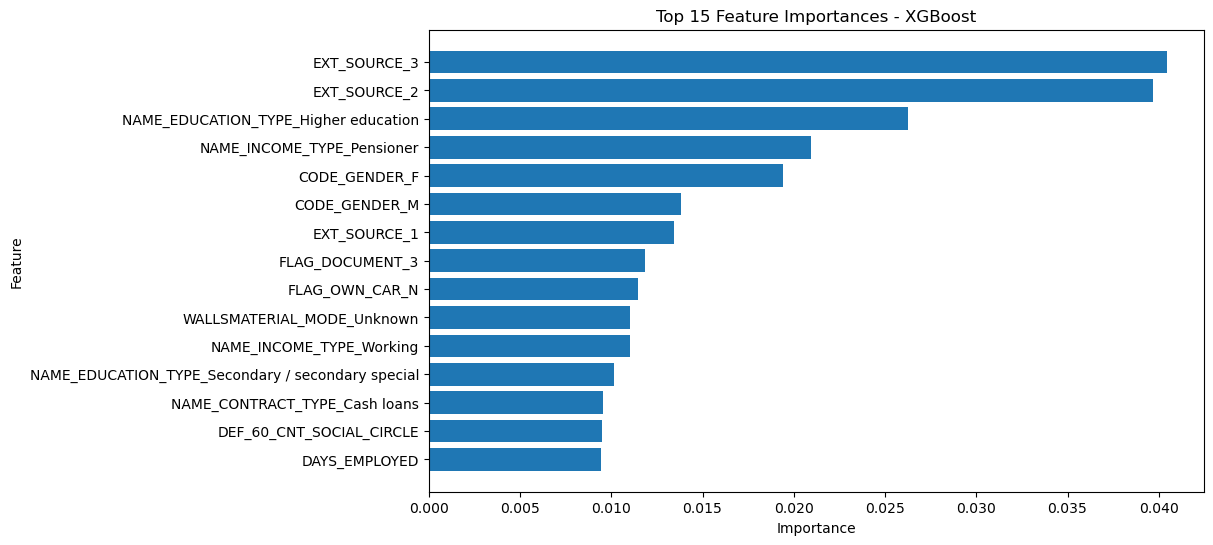

In [155]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - XGBoost")
plt.gca().invert_yaxis()
plt.show()

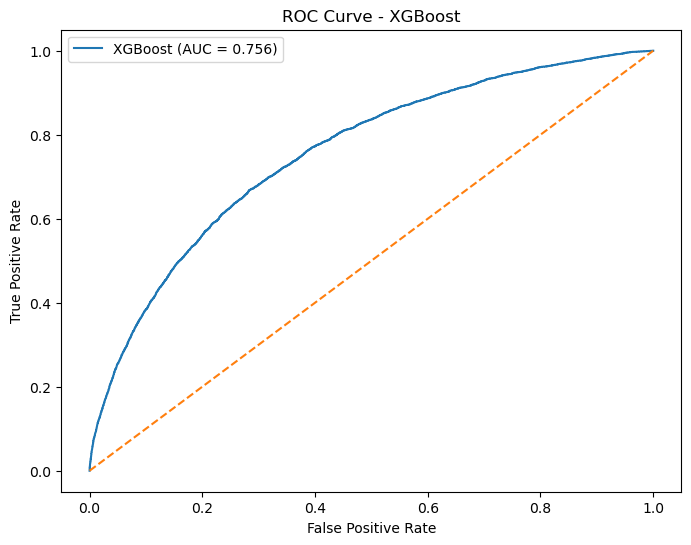

In [156]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

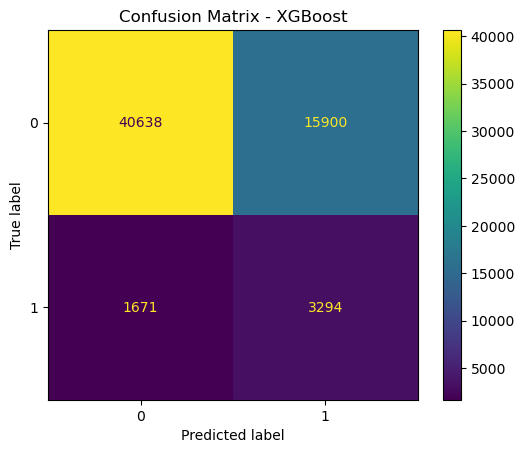

In [157]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb
)

plt.title("Confusion Matrix - XGBoost")
plt.show()

In [158]:
feature_columns = x_train.columns.tolist()

In [159]:
len(feature_columns)

237

In [160]:
x_train.shape

(246008, 237)

## 19. Feature Importance

In [161]:
def predict_customer(customer_data):
    customer_df = pd.DataFrame([customer_data])
    
    customer_df = customer_df.reindex(columns=feature_columns, fill_value=0)
    
    customer_scaled = loaded_scaler.transform(customer_df)
    
    prediction = loaded_model.predict(customer_scaled)[0]
    probability = loaded_model.predict_proba(customer_scaled)[0][1]
    
    return prediction, probability

In [162]:
customer = x_test.iloc[0].to_dict()

In [163]:
prediction, probability = predict_customer(customer)

print("Prediction:", prediction)
print("Probability of Class 1:", probability)

Prediction: 0
Probability of Class 1: 0.37711483


In [164]:
print("Actual:", y_test.iloc[0])
print("Predicted:", prediction)

Actual: 0
Predicted: 0


## 20. Conclusion

- The Home Credit dataset was analyzed and prepared for machine learning.
- Missing values, categorical variables, and feature engineering were handled during preprocessing.
- Logistic Regression, Random Forest, and XGBoost models were trained and evaluated.
- XGBoost achieved an ROC-AUC score of approximately 0.756.
- Precision, recall, F1-score, confusion matrix, and ROC-AUC were used to evaluate model performance.
- Feature importance analysis was performed to identify influential features.
- The final XGBoost model and scaler were saved using Joblib for future predictions.